In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

with open("census-bureau.columns", "r", encoding="utf-8") as f:
    cols = [line.strip() for line in f if line.strip()]

# 2) Read data using those names
df = pd.read_csv(
    "census-bureau.data",
    header=None,
    names=cols,
    sep=",",
    skipinitialspace=True
)

print(df.shape)
print(df.head())

(199523, 42)
   age                 class of worker  detailed industry recode  \
0   73                 Not in universe                         0   
1   58  Self-employed-not incorporated                         4   
2   18                 Not in universe                         0   
3    9                 Not in universe                         0   
4   10                 Not in universe                         0   

   detailed occupation recode                   education  wage per hour  \
0                           0        High school graduate              0   
1                          34  Some college but no degree              0   
2                           0                  10th grade              0   
3                           0                    Children              0   
4                           0                    Children              0   

  enroll in edu inst last wk   marital stat          major industry code  \
0            Not in universe        Widowed  

In [3]:
df.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

## Segmentation is really a two part problem
- First, we need to figure out how to encode our data for the best representation. 
- Two, we need to figure out if there are any natural clusters given that representation.

### First lets encode our data for the best representation.
- We need to keep in mind that columns such as age will be in the same dimension while some numerical columns such as detailed industry recode which are actually nominal will need to be one-hot encoded.
- We will also need to be careful about how we employ the weight column in the clustering algorithm as it is not a feature but rather a representation of how many people in the population have that particular row's features.
- Given that it is also a largely a play in dimensionality, we wil focus categories that provide the most information. For example, a column that is just two values and 90% of it is one value is not going to be very useful for clustering. 

In [4]:
for col in df.columns:
    print(f"{col}: {df[col].value_counts(normalize=True, dropna=False).head(3)}")

age: age
34    0.017487
35    0.017291
36    0.016805
Name: proportion, dtype: float64
class of worker: class of worker
Not in universe                   0.502423
Private                           0.361001
Self-employed-not incorporated    0.042326
Name: proportion, dtype: float64
detailed industry recode: detailed industry recode
0     0.504624
33    0.085554
43    0.041514
Name: proportion, dtype: float64
detailed occupation recode: detailed occupation recode
0     0.504624
2     0.043885
26    0.039529
Name: proportion, dtype: float64
education: education
High school graduate          0.242614
Children                      0.237677
Some college but no degree    0.139433
Name: proportion, dtype: float64
wage per hour: wage per hour
0      0.943345
500    0.003679
600    0.002737
Name: proportion, dtype: float64
enroll in edu inst last wk: enroll in edu inst last wk
Not in universe          0.936950
High school              0.034542
College or university    0.028508
Name: proportion, 

In [23]:
# Numerical columns
numerical_cols = ['age', 'capital gains', 'capital losses', 'dividends from stocks', 'weeks worked in year', 'wage per hour']
categorical_cols = ['major occupation code', 'major industry code', 'education', 'detailed household summary in household', 'detailed household and family stat', 'tax filer stat', 'full or part time employment stat', 'race', 'marital stat', 'veterans benefits', 'country of birth self', 'citizenship' ]

In [24]:
for col in numerical_cols:
    print(f"{col}: {df[col].isna().sum()} missing values, mean: {df[col].mean()}, std: {df[col].std()}")

age: 0 missing values, mean: 34.494198663813194, std: 22.310895206650287
capital gains: 0 missing values, mean: 434.7189897906507, std: 4697.5312797125325
capital losses: 0 missing values, mean: 37.313788385298935, std: 271.8964283649651
dividends from stocks: 0 missing values, mean: 197.52953293605248, std: 1984.16365838234
weeks worked in year: 0 missing values, mean: 23.174897129654227, std: 24.411488167504203
wage per hour: 0 missing values, mean: 55.426908175999756, std: 274.8964539028419


In [25]:
for col in categorical_cols:
    print(f"{col}: {df[col].isna().sum()} missing values, unique values: {df[col].nunique()}")

major occupation code: 0 missing values, unique values: 15
major industry code: 0 missing values, unique values: 24
education: 0 missing values, unique values: 17
detailed household summary in household: 0 missing values, unique values: 8
detailed household and family stat: 0 missing values, unique values: 38
tax filer stat: 0 missing values, unique values: 6
full or part time employment stat: 0 missing values, unique values: 8
race: 0 missing values, unique values: 5
marital stat: 0 missing values, unique values: 7
veterans benefits: 0 missing values, unique values: 3
country of birth self: 0 missing values, unique values: 43
citizenship: 0 missing values, unique values: 5


In [26]:
for c in numerical_cols + categorical_cols:
    print(f"column: {c}, dtype: {df[c].dtype}, ")

column: age, dtype: int64, 
column: capital gains, dtype: int64, 
column: capital losses, dtype: int64, 
column: dividends from stocks, dtype: int64, 
column: weeks worked in year, dtype: int64, 
column: wage per hour, dtype: int64, 
column: major occupation code, dtype: str, 
column: major industry code, dtype: str, 
column: education, dtype: str, 
column: detailed household summary in household, dtype: str, 
column: detailed household and family stat, dtype: str, 
column: tax filer stat, dtype: str, 
column: full or part time employment stat, dtype: str, 
column: race, dtype: str, 
column: marital stat, dtype: str, 
column: veterans benefits, dtype: str, 
column: country of birth self, dtype: str, 
column: citizenship, dtype: str, 


In [27]:
df["veterans benefits"] = df["veterans benefits"].astype(str)


In [28]:
# One Hot Encode categorical columns
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
# Combine with numerical columns
df_final = pd.concat([df[numerical_cols], df_encoded], axis=1)
print(df_final.shape)
print(df_final.head())

(199523, 173)
   age  capital gains  capital losses  dividends from stocks  \
0   73              0               0                      0   
1   58              0               0                      0   
2   18              0               0                      0   
3    9              0               0                      0   
4   10              0               0                      0   

   weeks worked in year  wage per hour  major occupation code_Armed Forces  \
0                     0              0                               False   
1                    52              0                               False   
2                     0              0                               False   
3                     0              0                               False   
4                     0              0                               False   

   major occupation code_Executive admin and managerial  \
0                                              False      
1             

In [29]:
# Lets scale the numerical features before applying PCA and t-SNE
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_final[numerical_cols] = scaler.fit_transform(df_final[numerical_cols])

### Okay now that we have a representation, we can start to look for clusters.
- First lets use PCA, t-SNE to reduce the dimensionality of our data and see if there are any natural clusters.

### This is actually a really cool plot, normally PCA doesn't reveal such clusters in my experience but here we can see some pretty distinct clusters. We can also see that there are some outliers in the data which is interesting.

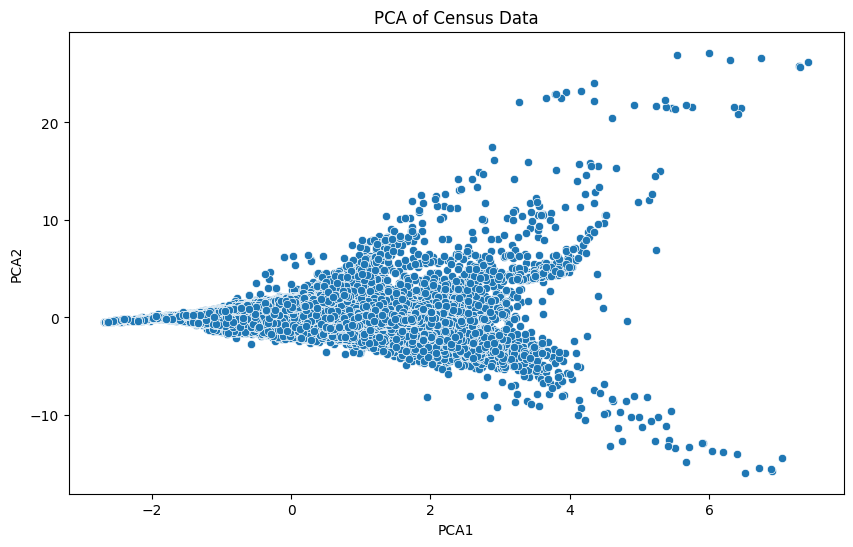

In [30]:
# Employ PCA to reduce dimensionality and visualize clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_final)
df_pca = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', data=df_pca)
plt.title('PCA of Census Data')
plt.show()

### t-SNE is just beautiful, we can see some really distinct clusters here.

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=-1, negative_gradient_method='fft',
     random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 17.12 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 3.49 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.08 seconds
===> Running optimization with exaggeration=12.00, lr=16626.92 for 250 iterations...
Iteration   50, KL divergence 6.5981, 50 iterations in 2.3806 sec
Iteration  100, KL divergence 5.9954, 50 iterations in 2.6437 sec
Iteration  150, KL divergence 5.7121, 50 iterations in 2.5663 sec
Iteration  200, KL divergence 5.5641, 50 iterations in 2.4450 sec
Iteration  250, KL divergence 5.4606, 50 iterations in 2.5385 sec
   --> Time elapsed: 12.57 seconds
===>

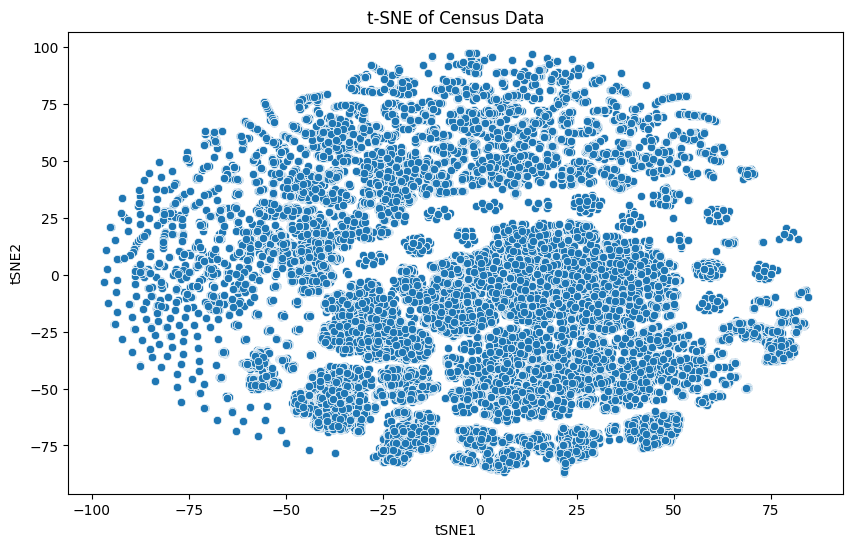

In [31]:
# t-SNE for non-linear dimensionality reduction
from openTSNE import TSNE

tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, 
            negative_gradient_method='fft', verbose=True)
tsne_result = tsne.fit(df_final.values.astype(np.float32))
df_tsne = pd.DataFrame(data=tsne_result, columns=['tSNE1', 'tSNE2'])
plt.figure(figsize=(10,6))
sns.scatterplot(x='tSNE1', y='tSNE2', data=df_tsne)
plt.title('t-SNE of Census Data')
plt.show()

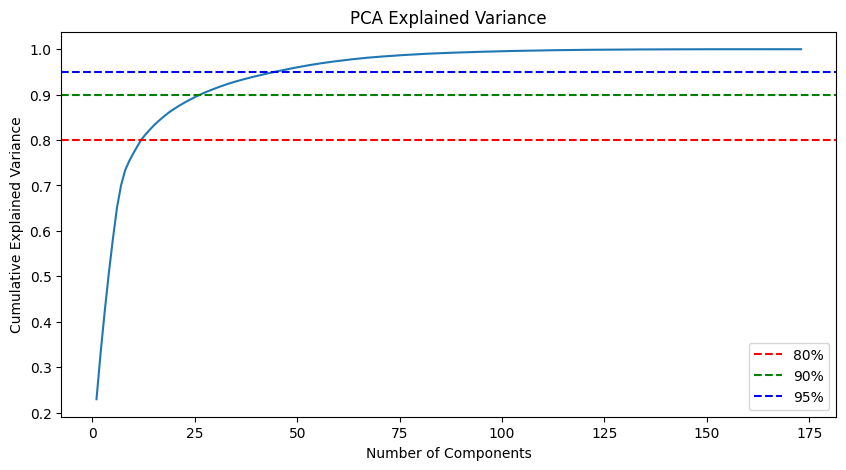

80% variance: 12 components
90% variance: 27 components
95% variance: 45 components


In [32]:
# Explained variance to determine number of components for PCA

pca_full = PCA(random_state=42)
pca_full.fit(df_final.values.astype(np.float32))

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar)
plt.axhline(0.80, color='r', linestyle='--', label='80%')
plt.axhline(0.90, color='g', linestyle='--', label='90%')
plt.axhline(0.95, color='b', linestyle='--', label='95%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"{threshold*100:.0f}% variance: {n} components")


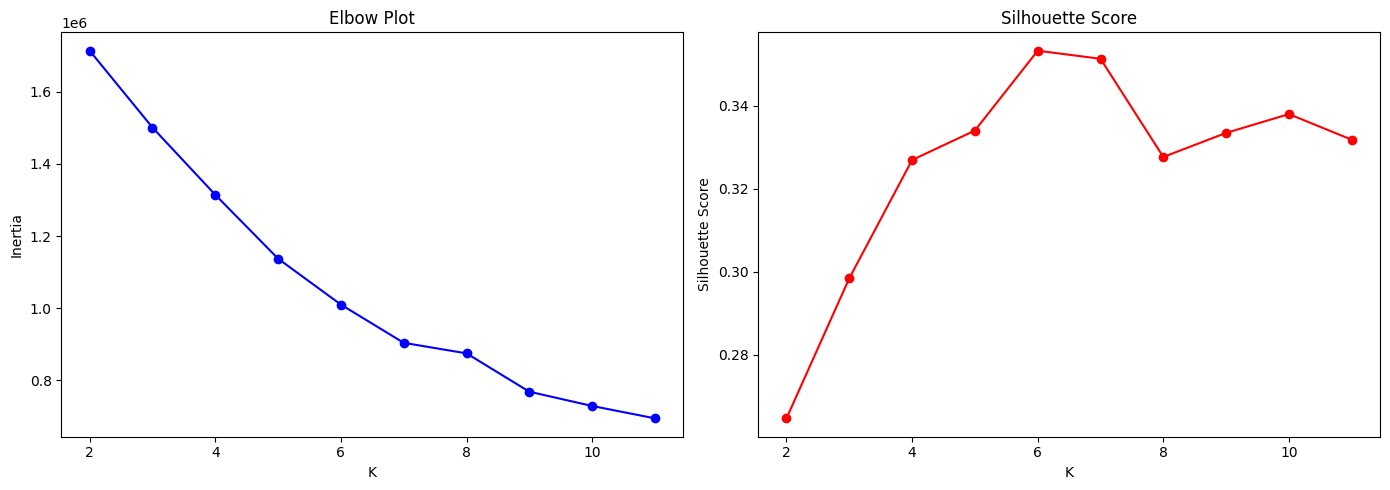

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 12)

pca_28 = PCA(n_components=28, random_state=42)
pca_result = pca_28.fit_transform(df_final.values.astype(np.float32))
df_pca_28 = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(28)])


for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca_28)
    inertias.append(km.inertia_)
    # silhouette is expensive on 200K rows — subsample
    sample_idx = np.random.choice(len(df_pca_28), size=10000, replace=False)
    silhouettes.append(silhouette_score(df_pca_28.iloc[sample_idx], labels[sample_idx]))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Plot')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()


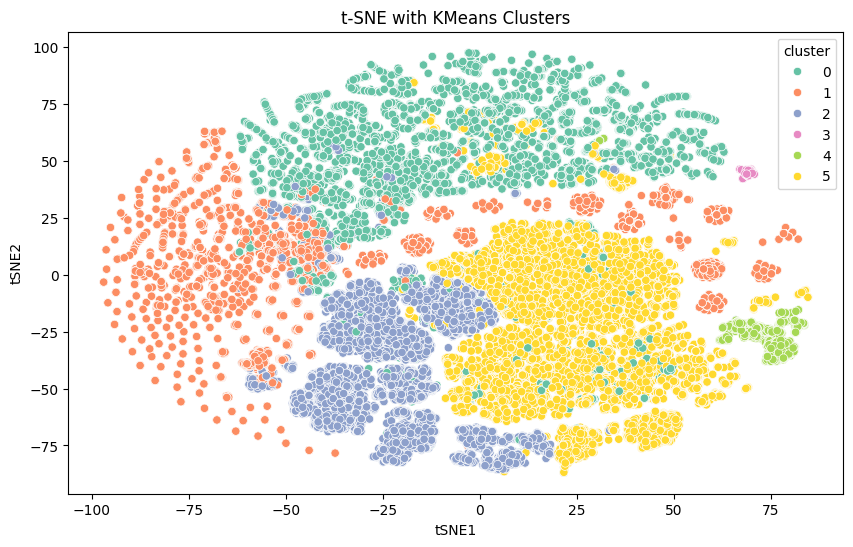

In [38]:
# Lets use K=4 based on the elbow and silhouette plots
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_pca_28['cluster'] = kmeans.fit_predict(df_pca_28)
plt.figure(figsize=(10,6))
# Plot on t-SNE for better visualization
sns.scatterplot(x=df_tsne['tSNE1'], y=df_tsne['tSNE2'], hue=df_pca_28['cluster'], palette='Set2', legend='full')
plt.title('t-SNE with KMeans Clusters')
plt.show()

In [39]:
# Attach cluster labels back to original df
df_profile = df[numerical_cols + categorical_cols].copy()
df_profile['cluster'] = df_pca_28['cluster'].values

# Numerical: mean per cluster
print(df_profile.groupby('cluster')[numerical_cols].mean().round(1).to_string())

# Categorical: mode (most common value) per cluster
cat_mode = df_profile.groupby('cluster')[categorical_cols].agg(
    lambda x: x.value_counts().index[0]
)
print(cat_mode.to_string())

# Size of each cluster
print("\nCluster sizes:")
print(df_profile['cluster'].value_counts().sort_index())

# Income label distribution per cluster
df_profile['high_income'] = (df['label'] == '50000+.').astype(int)
print("\n% earning >50K per cluster:")
print(df_profile.groupby('cluster')['high_income'].mean().mul(100).round(1))

          age  capital gains  capital losses  dividends from stocks  weeks worked in year  wage per hour
cluster                                                                                                 
0        60.0          160.1             0.5                  470.1                   1.6            0.6
1         9.3            2.6             0.0                    1.9                   0.5            1.4
2        33.7          348.7             0.9                   94.1                  45.2          116.4
3        46.8        99630.8             0.0                 5346.4                  47.4           24.7
4        44.0            0.0          1943.0                  727.9                  41.7           79.4
5        41.6          496.9             0.0                  192.2                  48.0          114.0
          major occupation code          major industry code                   education detailed household summary in household     detailed household and fami

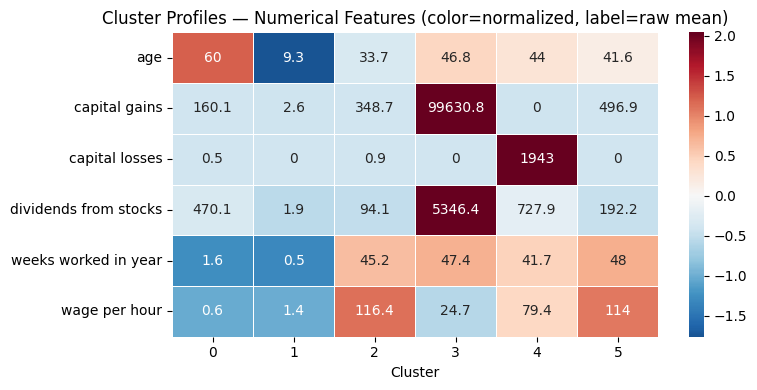

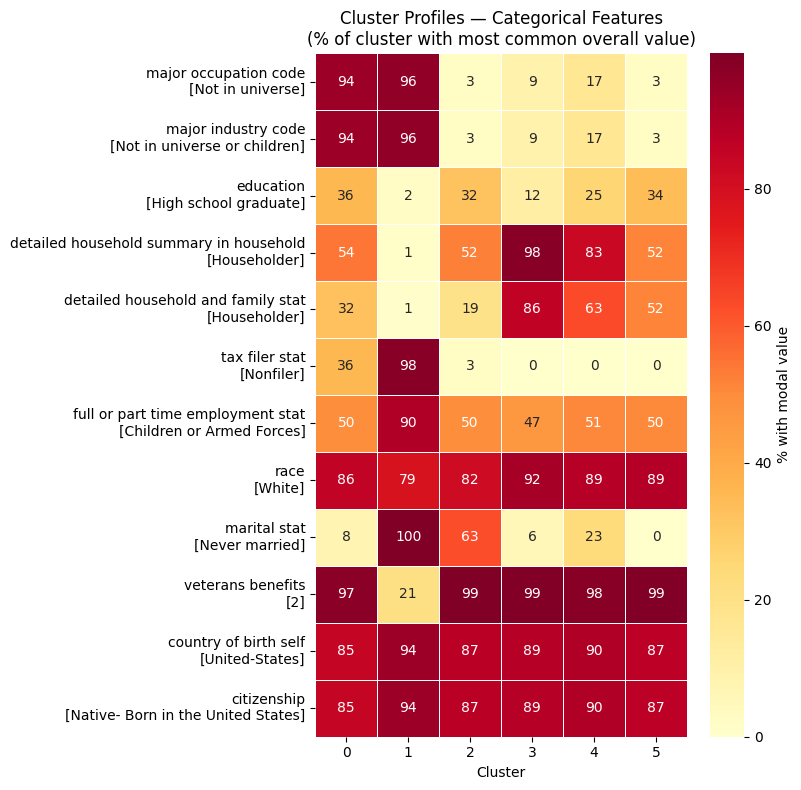

In [40]:
cluster_num = df_profile.groupby('cluster')[numerical_cols].mean()
cluster_num_norm = (cluster_num - cluster_num.mean()) / cluster_num.std()

plt.figure(figsize=(8, 4))
sns.heatmap(cluster_num_norm.T, annot=cluster_num.T.round(1), fmt='g',
            cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Cluster Profiles — Numerical Features (color=normalized, label=raw mean)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

cat_pct = {}
for col in categorical_cols:
    # for each cluster, % of rows with the overall modal value
    mode_val = df_profile[col].value_counts().index[0]
    cat_pct[f"{col}\n[{mode_val}]"] = (
        df_profile.groupby('cluster')[col]
        .apply(lambda x: (x == mode_val).mean() * 100)
    )

cat_pct_df = pd.DataFrame(cat_pct).T  # features × clusters

plt.figure(figsize=(8, 8))
sns.heatmap(cat_pct_df, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% with modal value'})
plt.title('Cluster Profiles — Categorical Features\n(% of cluster with most common overall value)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

In [41]:
df_profile['high_income'] = (df['label'] == '50000+.').astype(int)
print(df_profile.groupby('cluster')['high_income'].mean().rename('% >50K'))


cluster
0    0.017870
1    0.000100
2    0.057866
3    0.882653
4    0.304496
5    0.141849
Name: % >50K, dtype: float64


In [43]:
df['label'].value_counts(normalize=True)

label
- 50000.    0.937942
50000+.     0.062058
Name: proportion, dtype: float64

In [44]:
df_profile['low_income'] = (df['label'] == '- 50000.').astype(int)
print(df_profile.groupby('cluster')['low_income'].mean().rename('% <50K'))

cluster
0    0.982130
1    0.999900
2    0.942134
3    0.117347
4    0.695504
5    0.858151
Name: % <50K, dtype: float64
